In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy import stats
import pingouin as pg
import xarray as xr
import numpy as np

In [6]:
ndvi_path = '/Users/tillweiss/Desktop/MODSNOW/data/NDVI_amplitude_mean.nc'
ds = xr.open_dataset(ndvi_path)
ds

<xarray.Dataset> Size: 9kB
Dimensions:              (time: 588)
Coordinates:
  * time                 (time) object 5kB 2000-02-18 00:00:00 ... 2025-08-29...
Data variables:
    NDVI_amplitude_mean  (time) float64 5kB ...

In [2]:
ndvi_path = '/Users/tillweiss/Desktop/MODSNOW/data/ndvi_veg_timeseries.nc'
ds = xr.open_dataset(ndvi_path)
ds

<xarray.Dataset> Size: 9kB
Dimensions:        (time: 588)
Coordinates:
  * time           (time) object 5kB 2000-02-18 00:00:00 ... 2025-08-29 00:00:00
Data variables:
    NDVI_veg_mean  (time) float64 5kB ...
Attributes:
    description:  Vegetation-only spatial mean time series. Vegetated pixels ...

In [7]:
ndvi = ds[['NDVI_amplitude_mean']].to_dataframe().reset_index()

ndvi['Date'] = ndvi['time'].apply(lambda x: pd.Timestamp(x.isoformat()))
ndvi['Year'] = ndvi['Date'].dt.year
ndvi['Month'] = ndvi['Date'].dt.month

ndvi

,time,NDVI_amplitude_mean,Date,Year,Month
0,2000-02-18 00:00:00,0.102770,2000-02-18,2000,2
1,2000-03-05 00:00:00,0.107185,2000-03-05,2000,3
2,2000-03-21 00:00:00,0.118592,2000-03-21,2000,3
3,2000-04-06 00:00:00,0.155919,2000-04-06,2000,4
4,2000-04-22 00:00:00,0.218014,2000-04-22,2000,4
...,...,...,...,...,...
583,2025-06-26 00:00:00,0.350036,2025-06-26,2025,6
584,2025-07-12 00:00:00,0.381622,2025-07-12,2025,7
585,2025-07-28 00:00:00,0.398996,2025-07-28,2025,7
586,2025-08-13 00:00:00,0.396599,2025-08-13,2025,8


In [8]:
snow_path = '/Users/tillweiss/Desktop/MODSNOW/data/snow_agg.csv'
snow = pd.read_csv(snow_path)
snow['Date'] = pd.to_datetime(snow['Date'])

snow['Month'] = snow['Date'].dt.month
snow['Year'] = snow['Date'].dt.year

In [10]:
ndvi_daily = ndvi[['Date', 'NDVI_amplitude_mean']].set_index('Date')
snow_daily = snow[['Date','Snow_Percent', 'Snow_16d']].set_index('Date')

ndvi_snow = ndvi_daily.join(snow_daily, how='left')
ndvi_snow = ndvi_snow[ndvi_snow.index.month.isin([3, 4, 5, 6, 7, 8])]

ndvi_snow

,NDVI_amplitude_mean,Snow_Percent,Snow_16d
Date,,,
2000-03-05,0.107185,66.54,53.382500
2000-03-21,0.118592,47.06,43.998750
2000-04-06,0.155919,40.63,33.395625
2000-04-22,0.218014,24.56,24.993125
2000-05-08,0.244283,16.48,13.888750
...,...,...,...
2025-06-26,0.350036,NaN,NaN
2025-07-12,0.381622,NaN,NaN
2025-07-28,0.398996,NaN,NaN


In [11]:
ndvi_snow = ndvi_snow.reset_index()
ndvi_snow['Month'] = ndvi_snow['Date'].dt.month
ndvi_snow['Year'] = ndvi_snow['Date'].dt.year
ndvi_snow

,Date,NDVI_amplitude_mean,Snow_Percent,Snow_16d,Month,Year
0,2000-03-05,0.107185,66.54,53.382500,3,2000
1,2000-03-21,0.118592,47.06,43.998750,3,2000
2,2000-04-06,0.155919,40.63,33.395625,4,2000
3,2000-04-22,0.218014,24.56,24.993125,4,2000
4,2000-05-08,0.244283,16.48,13.888750,5,2000
...,...,...,...,...,...,...
307,2025-06-26,0.350036,NaN,NaN,6,2025
308,2025-07-12,0.381622,NaN,NaN,7,2025
309,2025-07-28,0.398996,NaN,NaN,7,2025
310,2025-08-13,0.396599,NaN,NaN,8,2025


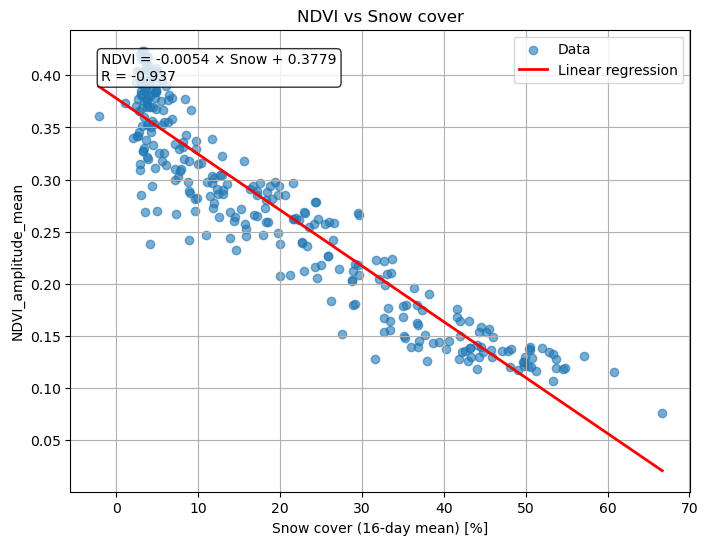

Pearson correlation: -0.937, p-value = 4.097e-141
Spearman correlation: -0.926, p-value = 8.283e-131
Regression slope: -0.0054
Regression intercept: 0.3779
Regression p-value: 4.097e-141


In [12]:
df_corr = ndvi_snow[['NDVI_amplitude_mean', 'Snow_16d']].dropna()

x = df_corr['Snow_16d']
y = df_corr['NDVI_amplitude_mean']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = intercept + slope * x_fit

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.6, label='Data')
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear regression')

plt.xlabel('Snow cover (16-day mean) [%]')
plt.ylabel('NDVI_amplitude_mean')
plt.title('NDVI vs Snow cover')
plt.grid(True)

plt.text(
    0.05, 0.95,
    f'NDVI = {slope:.4f} × Snow + {intercept:.4f}\n'
    f'R = {r_value:.3f}',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.legend()
plt.show()

pearson_coef, pearson_p = stats.pearsonr(x, y)
spearman_coef, spearman_p = stats.spearmanr(x, y)

print(f'Pearson correlation: {pearson_coef:.3f}, p-value = {pearson_p:.3e}')
print(f'Spearman correlation: {spearman_coef:.3f}, p-value = {spearman_p:.3e}')

print(f'Regression slope: {slope:.4f}')
print(f'Regression intercept: {intercept:.4f}')
print(f'Regression p-value: {p_value:.3e}')

Slightly better than from csv derived: 
- Pearson correlation: -0.929, p-value = 5.484e-155
- Spearman correlation: -0.893, p-value = 4.373e-125

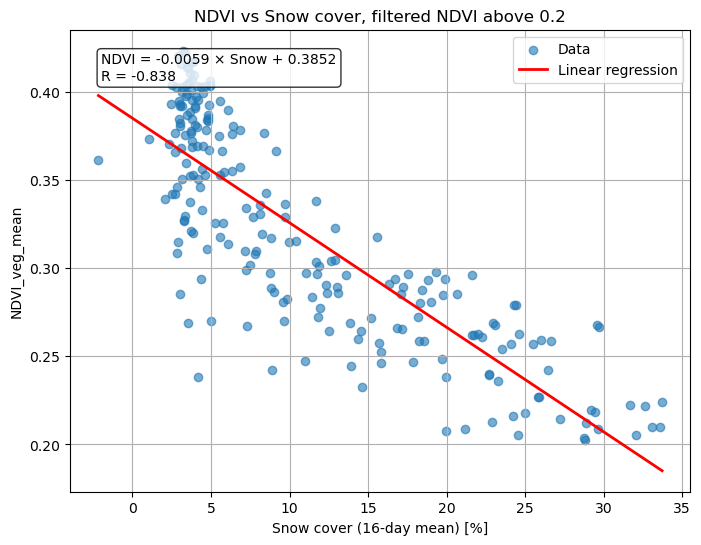

Pearson correlation: -0.838, p-value = 1.453e-60
Spearman correlation: -0.826, p-value = 1.888e-57
Regression slope: -0.0059
Regression intercept: 0.3852
Regression p-value: 1.453e-60


In [14]:
df_corr = ndvi_snow[['NDVI_amplitude_mean', 'Snow_16d']].dropna()
df_corr = df_corr[df_corr['NDVI_amplitude_mean'] >= 0.2]

x = df_corr['Snow_16d']
y = df_corr['NDVI_amplitude_mean']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = intercept + slope * x_fit

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.6, label='Data')
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear regression')

plt.xlabel('Snow cover (16-day mean) [%]')
plt.ylabel('NDVI_veg_mean')
plt.title('NDVI vs Snow cover, filtered NDVI above 0.2')
plt.grid(True)

plt.text(
    0.05, 0.95,
    f'NDVI = {slope:.4f} × Snow + {intercept:.4f}\n'
    f'R = {r_value:.3f}',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.legend()
plt.show()

pearson_coef, pearson_p = stats.pearsonr(x, y)
spearman_coef, spearman_p = stats.spearmanr(x, y)

print(f'Pearson correlation: {pearson_coef:.3f}, p-value = {pearson_p:.3e}')
print(f'Spearman correlation: {spearman_coef:.3f}, p-value = {spearman_p:.3e}')

print(f'Regression slope: {slope:.4f}')
print(f'Regression intercept: {intercept:.4f}')
print(f'Regression p-value: {p_value:.3e}')

In [22]:
march_snow = (
    ndvi_snow[ndvi_snow['Month'] == 3]
    .groupby(['Year', 'Month'])['Snow_Percent']
    .mean()
    .reset_index()
    .rename(columns={'Snow_Percent': 'March_Snow'})
    .drop(columns='Month')
)

months = [3, 4, 5, 6, 7, 8]
month_names = ['March', 'April', 'May', 'June', 'July', 'August']

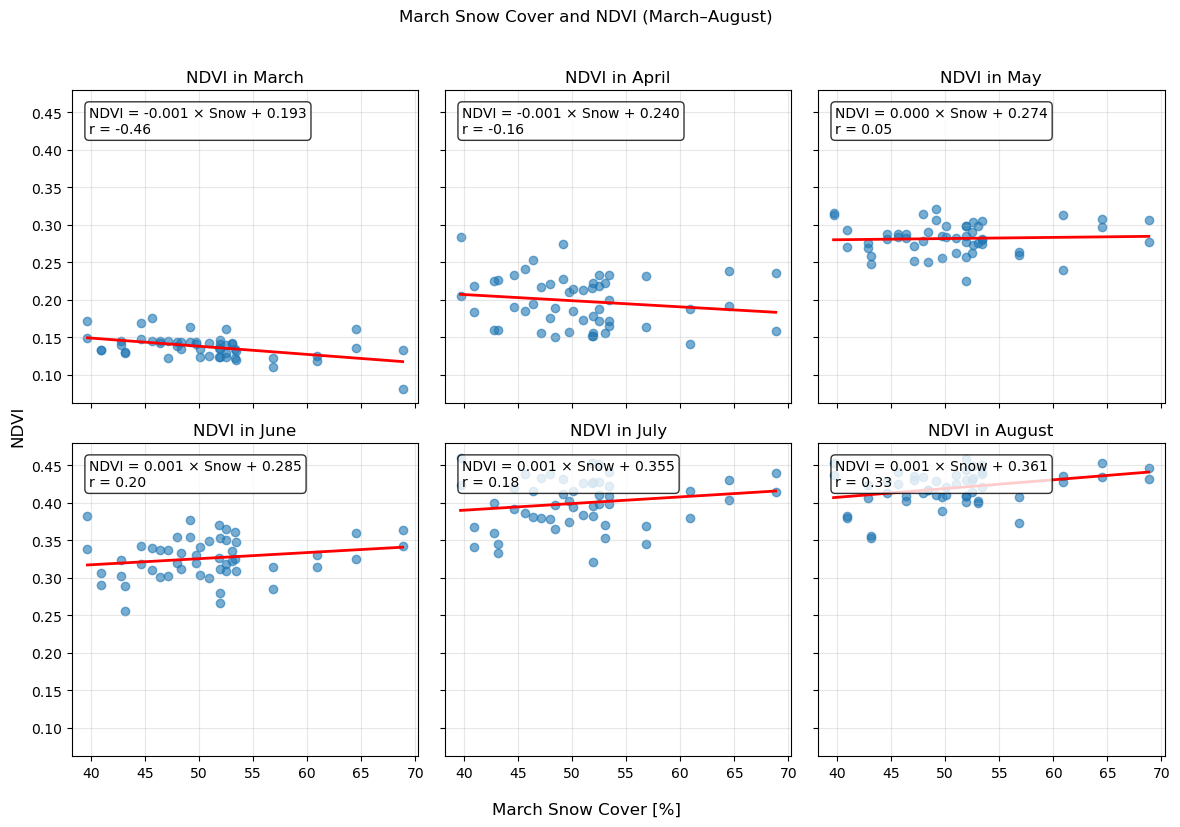

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, m, name in zip(axes, months, month_names):

    ndvi_m = ndvi_snow[ndvi_snow['Month'] == m]

    aligned = march_snow.merge(ndvi_m, on='Year', how='inner')

    x = aligned['March_Snow']
    y = aligned['NDVI_veg_mean']

    # Scatter
    ax.scatter(x, y, alpha=0.6)

    # Only fit regression if enough points
    if len(aligned) >= 3:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = intercept + slope * x_fit

        ax.plot(x_fit, y_fit, linewidth=2, color='r')

        ax.text(
            0.05, 0.95,
            f'NDVI = {slope:.3f} × Snow + {intercept:.3f}\n'
            f'r = {r_value:.2f}',
            transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
    else:
        ax.text(
            0.05, 0.95,
            'n < 3',
            transform=ax.transAxes,
            va='top', ha='left'
        )

    ax.set_title(f'NDVI in {name}')
    ax.grid(True, alpha=0.3)

fig.supxlabel('March Snow Cover [%]')
fig.supylabel('NDVI')
fig.suptitle('March Snow Cover and NDVI (March–August)', y=1.02)

plt.tight_layout()
plt.show()

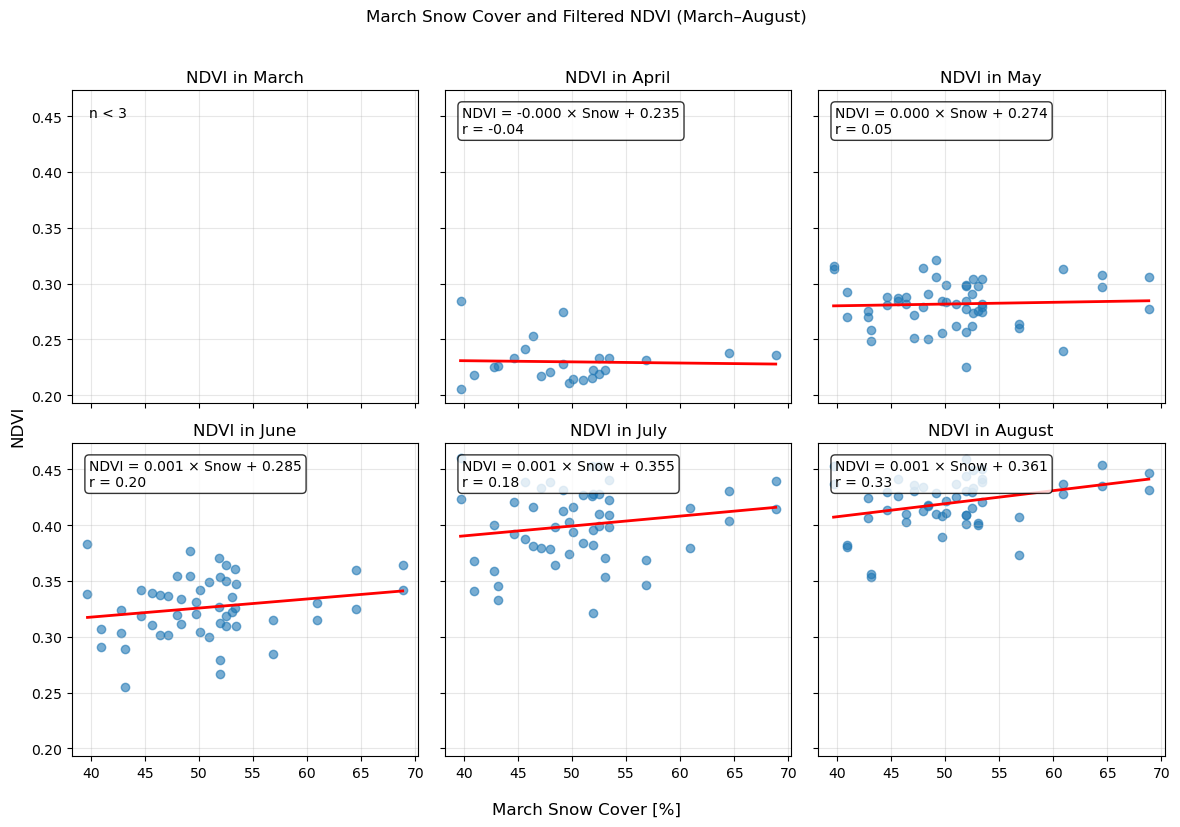

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, m, name in zip(axes, months, month_names):

    ndvi_m = (
        ndvi_snow[ndvi_snow['Month'] == m]
    )
    ndvi_m = ndvi_m[ndvi_m['NDVI_veg_mean'] >= 0.2]

    aligned = march_snow.merge(ndvi_m, on='Year', how='inner')

    x = aligned['March_Snow']
    y = aligned['NDVI_veg_mean']

    # Scatter
    ax.scatter(x, y, alpha=0.6)

    # Only fit regression if enough points
    if len(aligned) >= 3:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = intercept + slope * x_fit

        ax.plot(x_fit, y_fit, linewidth=2, color='r')

        ax.text(
            0.05, 0.95,
            f'NDVI = {slope:.3f} × Snow + {intercept:.3f}\n'
            f'r = {r_value:.2f}',
            transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
    else:
        ax.text(
            0.05, 0.95,
            'n < 3',
            transform=ax.transAxes,
            va='top', ha='left'
        )

    ax.set_title(f'NDVI in {name}')
    ax.grid(True, alpha=0.3)

fig.supxlabel('March Snow Cover [%]')
fig.supylabel('NDVI')
fig.suptitle('March Snow Cover and Filtered NDVI (March–August)', y=1.02)

plt.tight_layout()
plt.show()

- Vegetation-only spatial mean time series. Vegetated pixels defined as mean July–August NDVI > 0.2
- Filtered for summer vegetation pixels eg. pixels that are in June August above 0.2 NDVI
- Monthly correlations are actualy lower with excluded summer pixels than without 

In [17]:
ndvi_snow

,Date,NDVI_amplitude_mean,Snow_Percent,Snow_16d,Month,Year
0,2000-03-05,0.107185,66.54,53.382500,3,2000
1,2000-03-21,0.118592,47.06,43.998750,3,2000
2,2000-04-06,0.155919,40.63,33.395625,4,2000
3,2000-04-22,0.218014,24.56,24.993125,4,2000
4,2000-05-08,0.244283,16.48,13.888750,5,2000
...,...,...,...,...,...,...
307,2025-06-26,0.350036,NaN,NaN,6,2025
308,2025-07-12,0.381622,NaN,NaN,7,2025
309,2025-07-28,0.398996,NaN,NaN,7,2025
310,2025-08-13,0.396599,NaN,NaN,8,2025


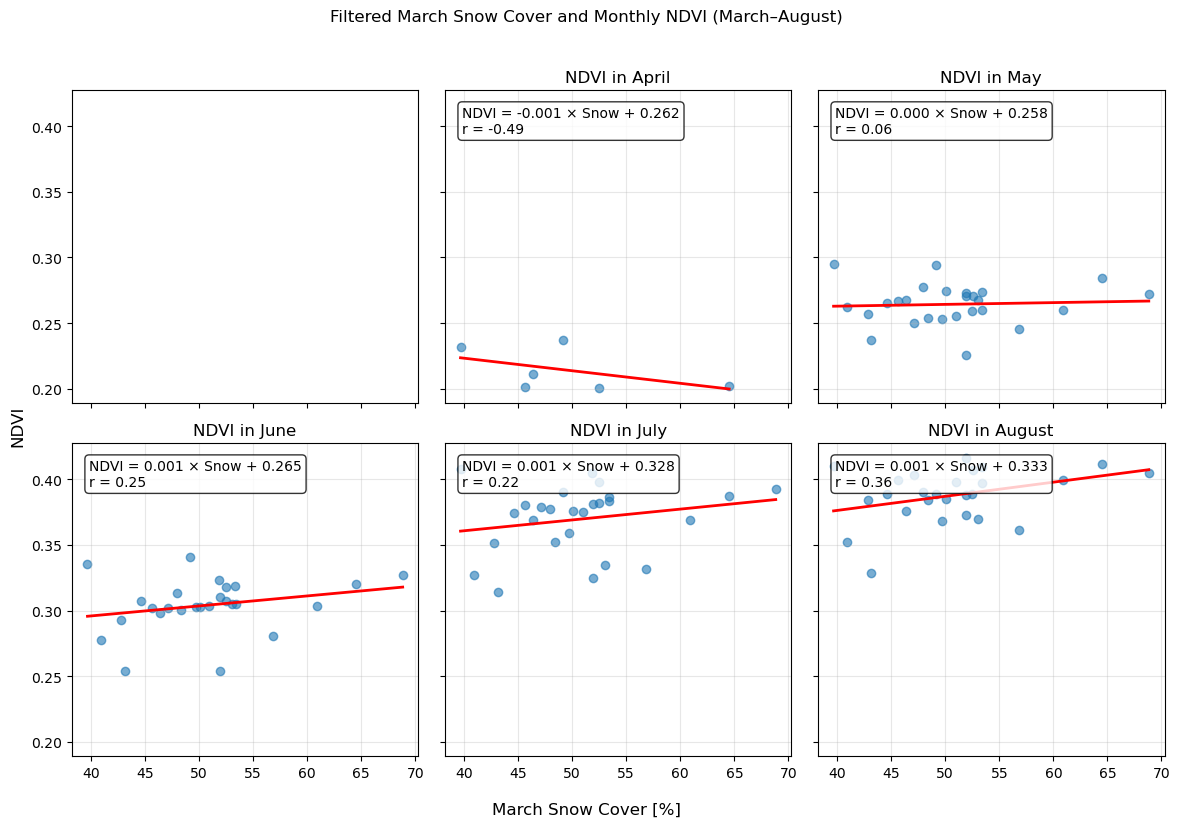

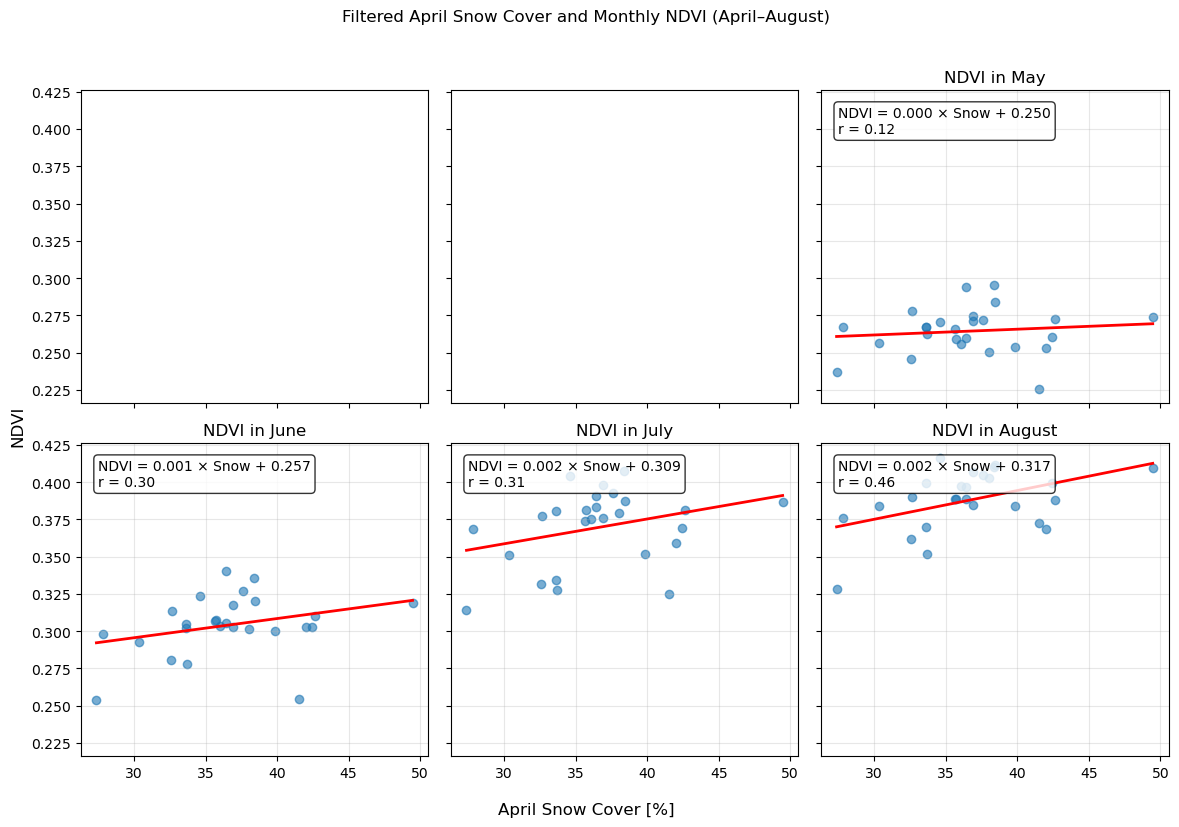

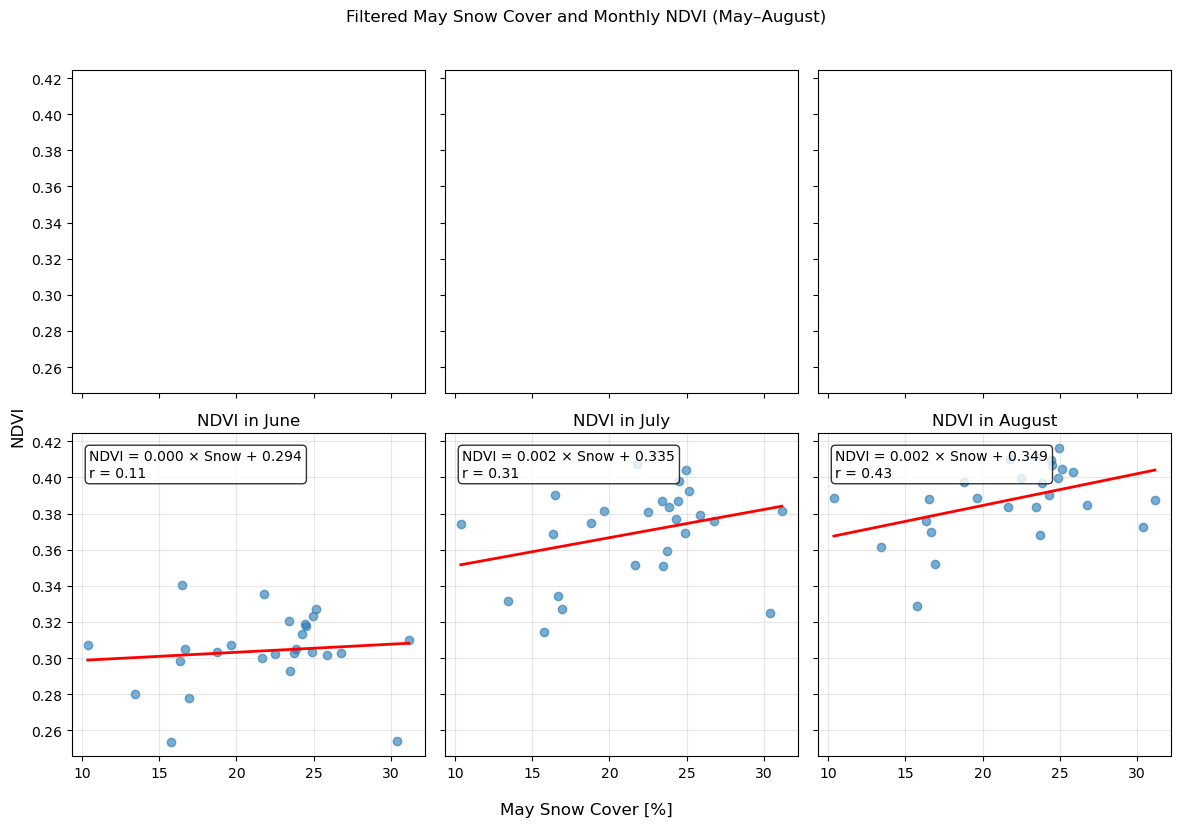

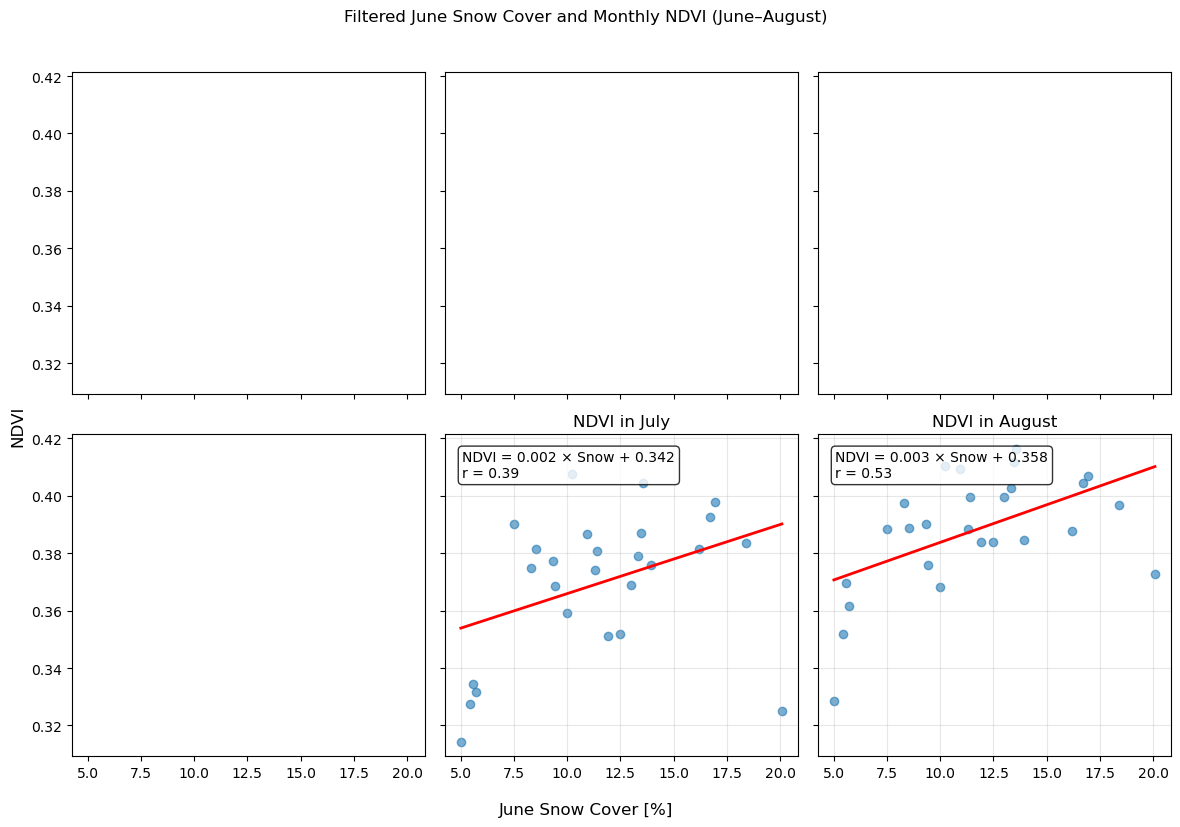

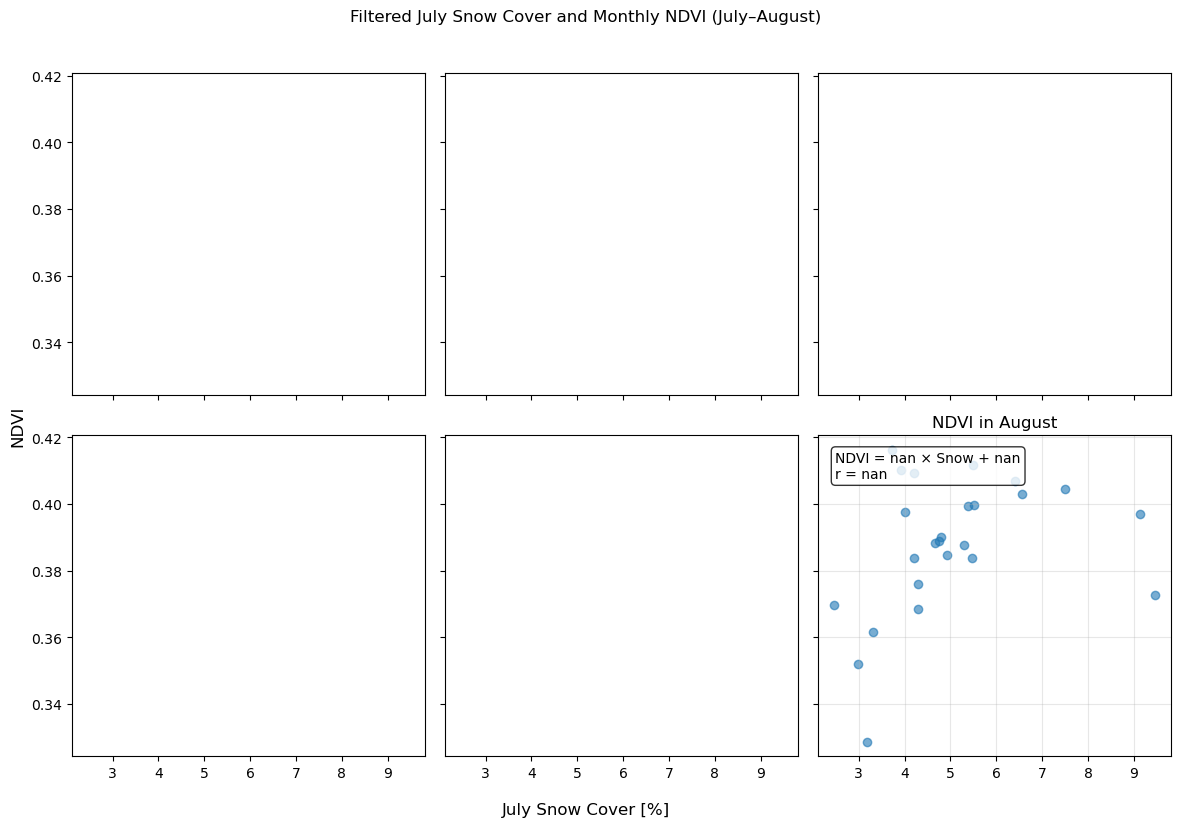

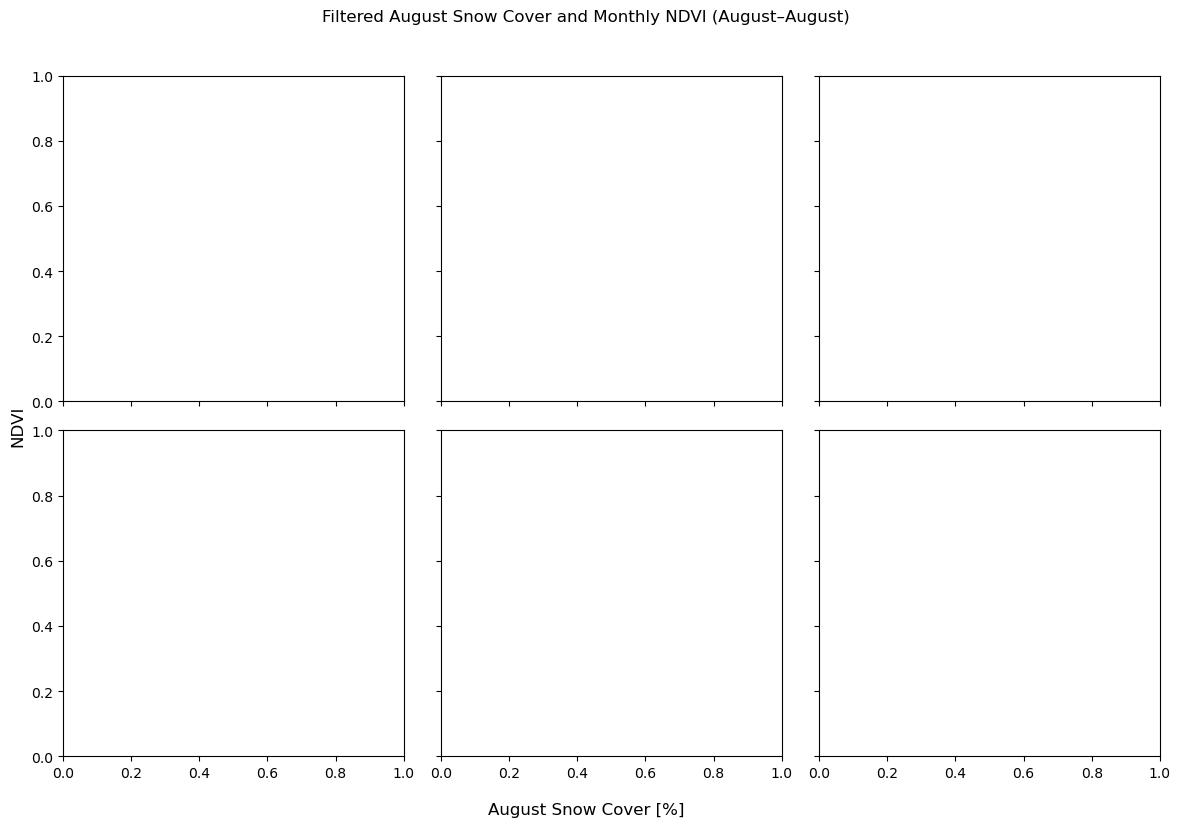

In [22]:
months = [3, 4, 5, 6, 7, 8]
month_names = ['March', 'April', 'May', 'June', 'July', 'August']

ndvi_monthly = (
    ndvi_snow
    .groupby(['Year', 'Month'], as_index=False)
    .agg(NDVI=('NDVI_amplitude_mean', 'mean'))  
)

for i, n in zip(months, month_names):

    month_snow = (
    ndvi_snow[ndvi_snow['Month'] == i]
    .groupby(['Year', 'Month'])['Snow_Percent']
    .mean()
    .reset_index()
    .rename(columns={'Snow_Percent': f'{n}_Snow'})
    .drop(columns='Month')
    )

    fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, m, name in zip(axes, months, month_names):

        if m <= i:
            continue

        ndvi_m = ndvi_monthly[ndvi_monthly['Month'] == m].copy()
        ndvi_m = ndvi_m[ndvi_m['NDVI'] >= 0.2]

        aligned = month_snow.merge(ndvi_m, on='Year', how='inner')

        x = aligned[f'{n}_Snow']
        y = aligned['NDVI']

        ax.scatter(x, y, alpha=0.6)

        if len(aligned) >= 3:
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = intercept + slope * x_fit

            ax.plot(x_fit, y_fit, linewidth=2, color='r')

            ax.text(
                0.05, 0.95,
                f'NDVI = {slope:.3f} × Snow + {intercept:.3f}\n'
                f'r = {r_value:.2f}',
                transform=ax.transAxes,
                va='top', ha='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )
        else:
            ax.text(
                0.05, 0.95,
                'n < 3',
                transform=ax.transAxes,
                va='top', ha='left'
            )

        ax.set_title(f'NDVI in {name}')
        ax.grid(True, alpha=0.3)

    fig.supxlabel(f'{n} Snow Cover [%]')
    fig.supylabel('NDVI')
    fig.suptitle(f'Filtered {n} Snow Cover and Monthly NDVI ({n}–August)', y=1.02)

    plt.tight_layout()
    plt.show()